In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from Src.data import load_csv_df
from Src.plotting import set_plotting_style

In [2]:
# Already prepared accent palette applying using function from mine Src module (plotting)
set_plotting_style()

In [3]:
FINAL_DF_PATH = "../Data/Final/final-data.csv"
UNSCALED_DF_PATH = "../Data/Processed/unscaled-data.csv"

# Safely loading dataframe using function from mine Src module (data)
final_df = load_csv_df(
    df_path=FINAL_DF_PATH,
)

# Loading raw data for analysis
raw_df = load_csv_df(
    df_path=UNSCALED_DF_PATH,
)

Successfully loaded dataframe: ..\Data\Final\final-data.csv
Dataframe has: 8950 rows / 7 columns
Dataframe size: 0.478MB
Successfully loaded dataframe: ..\Data\Processed\unscaled-data.csv
Dataframe has: 8950 rows / 17 columns
Dataframe size: 1.161MB


In [4]:
cluster_counts = final_df["cluster"].value_counts().sort_index()
cluster_pct = (final_df["cluster"].value_counts(normalize=True) * 100).round(2).sort_index()

distribution_df = pd.DataFrame({
    "Count": cluster_counts,
    "Percent {%)": cluster_pct,
})

print("Cluster distribution:")
display(distribution_df)

Cluster distribution:


,Count,Percent {%)
cluster,,
-1,1031,11.52
0,44,0.49
1,24,0.27
2,7851,87.72


In [5]:
clean_df = final_df[final_df["cluster"] != -1].copy()
noise_df = final_df[final_df["cluster"] == -1].copy()

print(f"Total object in clusters: {len(clean_df)} ({len(clean_df) / len(final_df) * 100:.1f}%)")
print(f"Total noise in clusters: {len(noise_df)} ({len(noise_df) / len(final_df) * 100:.1f}%)")

profiles_mean = clean_df.groupby("cluster").mean().round(3)

print("\nCluster profiles:")
display(profiles_mean)

Total object in clusters: 7919 (88.5%)
Total noise in clusters: 1031 (11.5%)

Cluster profiles:


,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6
cluster,,,,,,
0,0.247,-4.728,-0.300,-0.050,-0.824,-3.688
1,-3.091,-3.915,0.315,-0.498,-1.094,-2.751
2,0.047,0.100,-0.019,0.182,0.103,0.066


In [6]:
raw_df["cluster"] = final_df["cluster"].values
clean_raw_df = raw_df[raw_df["cluster"] != -1].copy()

raw_profiles = clean_raw_df.drop(columns=["CUST_ID"], errors="ignore").groupby("cluster").mean().T.round(2)

print("Real Features Profiles:")
display(raw_profiles)

Real Features Profiles:


cluster,0,1,2
BALANCE,2.12,78.66,1609.56
BALANCE_FREQUENCY,0.05,0.12,0.91
PURCHASES,187.76,0.03,967.72
ONEOFF_PURCHASES,1.04,0.03,562.72
INSTALLMENTS_PURCHASES,186.72,0.00,405.30
CASH_ADVANCE,0.00,1185.06,888.32
PURCHASES_FREQUENCY,0.42,0.00,0.49
ONEOFF_PURCHASES_FREQUENCY,0.00,0.00,0.20
PURCHASES_INSTALLMENTS_FREQUENCY,0.41,0.00,0.37
CASH_ADVANCE_FREQUENCY,0.00,0.10,0.13


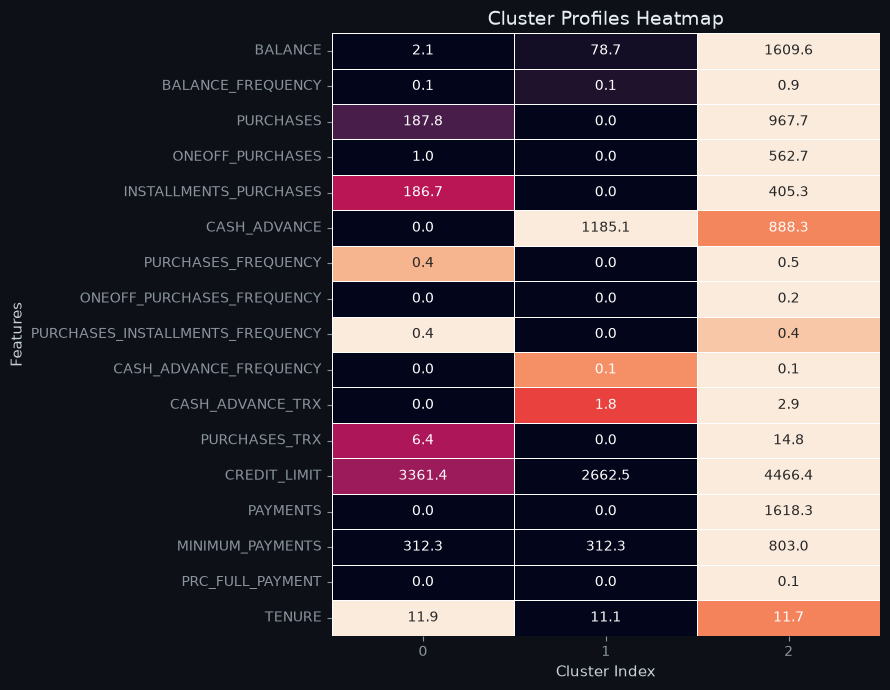

In [7]:
scaler = MinMaxScaler()
normalized_df = pd.DataFrame(
    scaler.fit_transform(raw_profiles.T).T,
    index=raw_profiles.index,
    columns=raw_profiles.columns
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    normalized_df,
    annot=raw_profiles,
    fmt=".1f",
    cbar=False,
    linewidths=0.5
)

plt.title("Cluster Profiles Heatmap")
plt.xlabel("Cluster Index")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

"""Cluster profiles heatmap results:

1. Cluster 0 is Installment-only users:
    - Low overall BALANCE (2.1$).
    - 0 CASH_ADVANCE, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PAYMENTS.
    - Low ONEOFF_PURCHASES, MINIMUM_PAYMENTS,  PRC_FULL_PAYMENT.
2. Cluster 1 is Cash borrowers using cards:
    - Mean CASH_ADVANCE is 1185.1 higher than first cluster.
    - CASH_ADVANCE_TRX (1.8) is included (Cluster 1 doesn't have it).
3. Cluster 2 is Active credit card users:
    - They are core segment (87.7%).
    - Leading in BALANCE (1609.6$), PURCHASES (967.7$) and CREDIT_LIMIT (4466.4$).
"""